In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('/content/Telco-Customer-Churn.csv')

**Inspection Of Data**

In [6]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Replacing blanks with 0 in TotalCharges as there Tenure column is 0

data['TotalCharges']=data['TotalCharges'].replace(' ','0')


In [9]:
# Also Converted the datatype

data['TotalCharges']=data['TotalCharges'].astype("float")

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# checked whether are data(columns) having null values or not ?

data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [12]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [13]:
data.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [14]:
data.duplicated().sum()

# Since there is no duplicated, i have done on the basis of rows

np.int64(0)

In [15]:
# Checking on the basis of unique values.

data['customerID'].duplicated().sum()

np.int64(0)

In [16]:
# Created a function for SeniorCitizen to convert values( 0 & 1) into Yess & No

def con(value):
  if value == 1:
    return "Yes"
  else:
    return "No"

In [17]:
data['SeniorCitizen'] = data['SeniorCitizen'].apply(con)

In [22]:
data.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
7,6713-OKOMC,Female,No,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,No
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


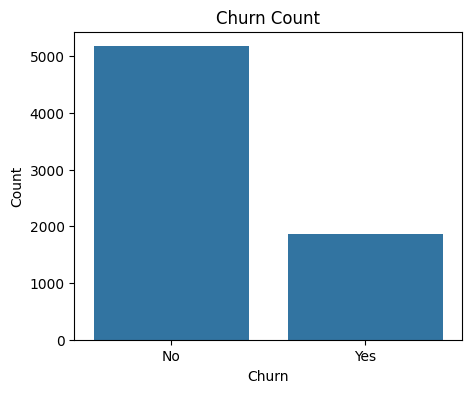

In [33]:
plt.figure(figsize=(5,4))
sns.countplot(x=data['Churn'])
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Count')
plt.show()

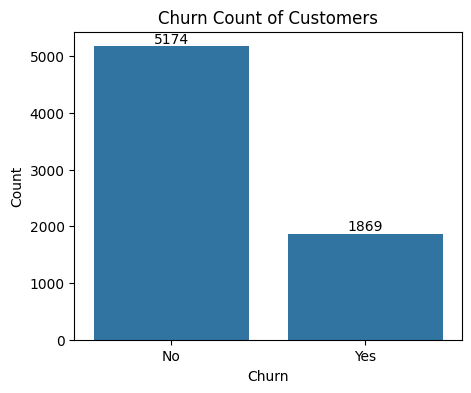

In [35]:
plt.figure(figsize=(5,4))
ax = sns.countplot(x='Churn', data=data)
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Churn Count of Customers')

# Added count/Label for each bar
ax.bar_label(ax.containers[0])

plt.show()


**Analysis:**
- **26.54%** (1869 out of 7043) customers has already churned out
- Remaining **73.46%** (5174 out of 7043) are still there.

In [21]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


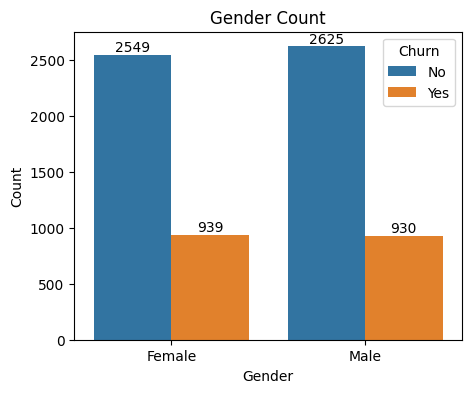

In [91]:
# checking on the basis of gender

plt.figure(figsize=(5,4))
ax=sns.countplot(x='gender',data=data, hue='Churn')
ax.bar_label(ax.containers[0])  # to get labe for blue
ax.bar_label(ax.containers[1])  # to get label for orange
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Gender Count')
plt.show()


**Analysis**
- Since both the male and female churn ratio / numbers are approximately same.

- we can say its not on the basis of specific gender.

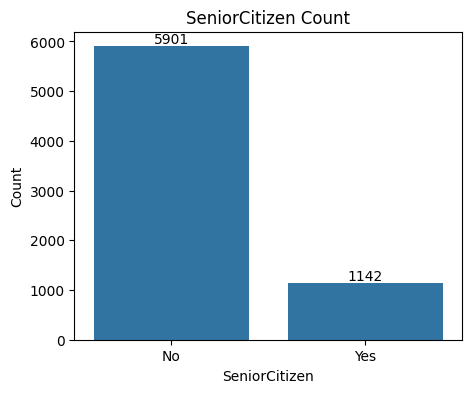

In [93]:
# on the basis of SeniorCitizen

plt.figure(figsize=(5,4))
ax = sns.countplot(x='SeniorCitizen',data=data)
ax.bar_label(ax.containers[0])
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.title('SeniorCitizen Count')
plt.show()

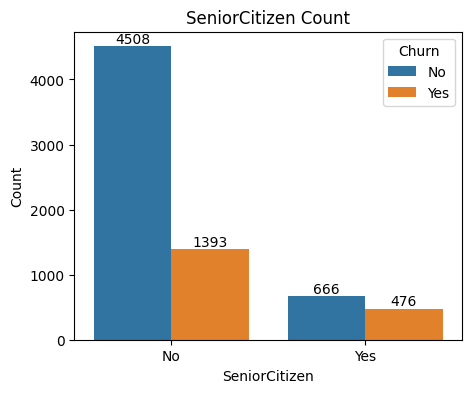

In [88]:
plt.figure(figsize=(5,4))
ax=sns.countplot(x='SeniorCitizen',data=data, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xlabel('SeniorCitizen')
plt.ylabel('Count')
plt.title('SeniorCitizen Count')
plt.show()


**Analysis**

- Percentage of 'No' for churned out (Non-Senior Citizen) is less then actual SeniorCitizen ('Yes').

- That means SeniorCitizen is more likely have higher rate of Churn percentage as compare to non-seniors.

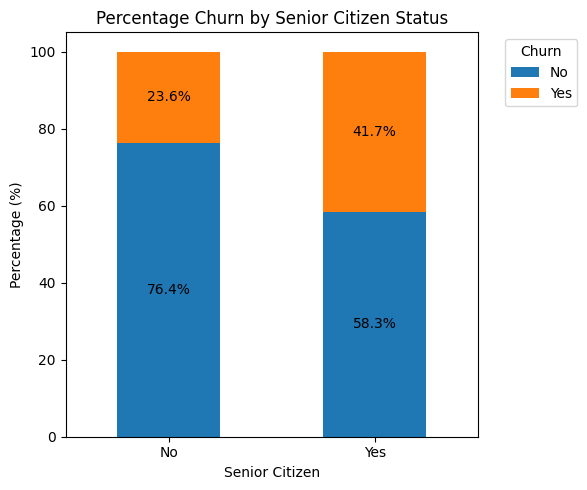

In [39]:
# Calculate percentages of Churn for each SeniorCitizen category
senior_churn_pct = data.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

# Plot stacked bar chart
ax = senior_churn_pct.plot(kind='bar', stacked=True, figsize=(6, 5), color=['#1f77b4', '#ff7f0e'])

plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.title('Percentage Churn by Senior Citizen Status')
plt.xticks(rotation=0)
plt.legend(title='Churn', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentage labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.tight_layout()
plt.show()

**Analysis:**
- Among non-senior citizens (`SeniorCitizen = No`), only about **23.6%** have churned.
- In contrast, among senior citizens (`SeniorCitizen = Yes`), almost **41.7%** have churned. This confirms that senior citizens have a significantly higher churn rate compared to non-seniors.

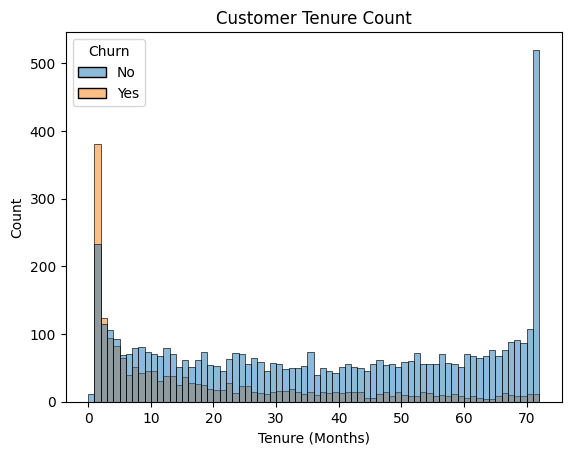

In [62]:
# on the basis of tenure

sns.histplot(x='tenure',data=data,bins = 72,hue='Churn')
plt.xlabel('Tenure (Months)')
plt.ylabel('Count')
plt.title('Customer Tenure Count')
plt.show()

**Analysis**

- People who have used our services for a long time have stayed.

- And People who used our services for a intitial stage ( 1 or 2 month) have churned approximately 40%.


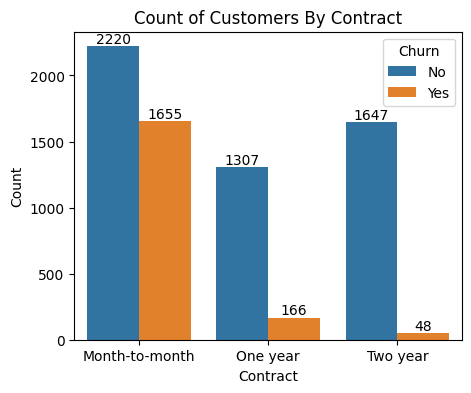

In [87]:
# Count of people on the basis of contract.

plt.figure(figsize=(5,4))
ax=sns.countplot(x='Contract',data=data, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xlabel('Contract')
plt.ylabel('Count')
plt.title('Count of Customers By Contract')
plt.show()



Analysis

 - Customes who have taken Month-to-month Plans have around 70% of churned ratio.

 - As Year Plan Have significantly very Low rate of churned percentage.

 - Conslusion - Sell the customers Longer Year Plans , make strategies and plans for this.

In [77]:
data.columns.values

# 'PhoneService', 'MultipleLines', 'InternetService',
       #'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       #'TechSupport', 'StreamingTV', 'StreamingMovies'

# These are those columns which need to be analysed , let go with ai.

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

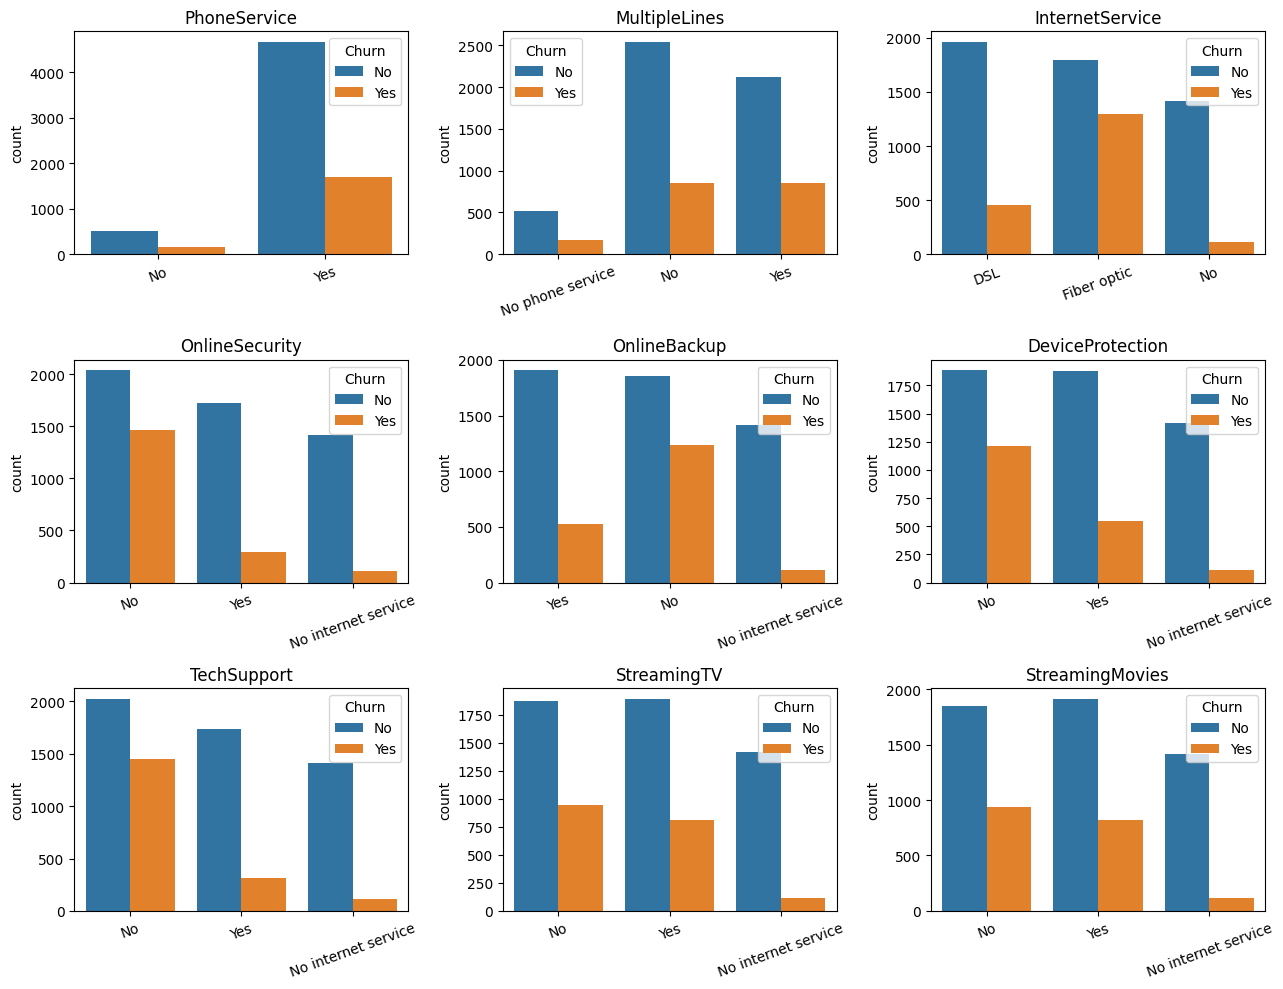

In [81]:
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    sns.countplot(data=data, x=col, ax=ax, hue= 'Churn')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Analysis**

- Internet service type matters most: Fiber optic customers churn the most (about 40% of them), against roughly 20% for DSL and under 10% for customers with no internet.

- Add-on services reduce churn: Customers without OnlineSecurity, TechSupport, OnlineBackup or DeviceProtection churn far more (about 40%) than those who have them (about 15-25%).

- Streaming TV and Movies show little difference: Churn is similar whether or not the customer has them (about 30%), so they are weak predictors.

- PhoneService and MultipleLines are weak predictors too: Most customers have phone service, and churn rates look similar across the categories.

- Customers with no internet service churn the least, in every category. The likely risk group is fiber optic customers without security or support add-ons.

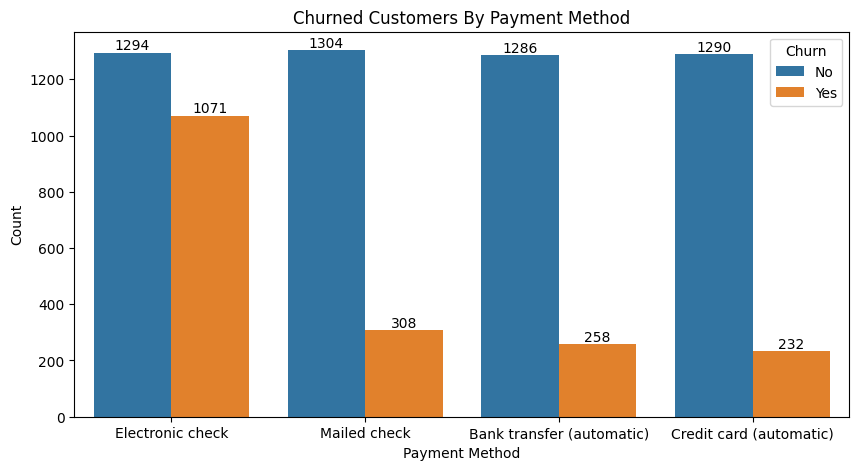

In [92]:
# using paymentmethod

plt.figure(figsize=(10,5))
ax=sns.countplot(x='PaymentMethod',data=data, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.title('Churned Customers By Payment Method')
plt.show()


**Analysis **

- Customer is More churned While using Electronic Check as Payment Method.